In [ ]:
# Problem 3

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

m = 1 # kg
k = 1 # N/m

In [ ]:
# Part A

def derivatives(t, S):

  x = S[0]
  v = S[1]
  a = -x * k / m

  return [v, a]

In [ ]:
# Part B

x0 = 1 # m
v0 = 0 # m/s
S0 = [x0, v0]

t0 = 0 #s
t1 = 20 #s
tpoints = np.arange(t0, t1, 1e-3)
tspan = [t0, t1]

solution = solve_ivp(derivatives, tspan, S0, t_eval = tpoints, method = 'RK45')
Sarray = solution.y.T

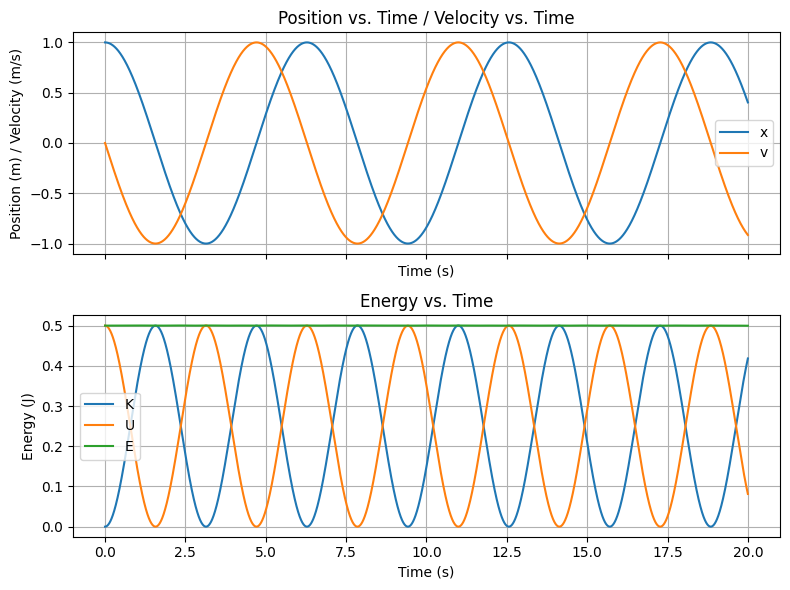

In [ ]:
# Part C

def energy(S):

  x = S[0]
  v = S[1]

  K = 0.5 * m * v * v
  U = 0.5 * k * x * x
  E = K + U

  return K, U, E

Ksol, Usol, Esol = energy(Sarray.T)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize = (8, 6), sharex = True)

ax1.plot(tpoints, Sarray[:,0], label = "x")
ax1.plot(tpoints, Sarray[:,1], label = "v")
ax1.set_ylabel("Position (m) / Velocity (m/s)")
ax1.set_xlabel("Time (s)")
ax1.set_title("Position vs. Time / Velocity vs. Time")
ax1.legend()
ax1.grid(True)

ax2.plot(tpoints, Ksol, label = "K")
ax2.plot(tpoints, Usol, label = "U")
ax2.plot(tpoints, Esol, label = "E")
ax2.set_ylabel("Energy (J)")
ax2.set_xlabel("Time (s)")
ax2.set_title("Energy vs. Time")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()